# **Imports**

In [68]:
!pip install scikit-learn seaborn

# Core imports
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# Data and computation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

# Machine learning utilities
from scipy.spatial.distance import cdist
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# System utilities
import os
import time
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

Using device: cpu
PyTorch version: 2.8.0+cu126


# **Dataset Loading**

🚀 Starting UNSUPERVISED dataset loading process...
Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted successfully!
📂 Loading Alzheimer's dataset from: /content/drive/MyDrive/Alzheimer_s Dataset.zip
📦 Extracting zip file...
✅ Extraction complete!
📋 Found 11519 image files in the dataset

🗂 Dataset structure:
alzheimer_dataset/
  Alzheimer_s Dataset/
⚠️ Found 11519 images, limiting to 5000 samples for training efficiency
🧠 Loading 5000 brain scan images for UNSUPERVISED learning...


Processing brain scans (unlabeled):   3%|▎         | 126/5000 [00:00<00:03, 1250.87it/s]

   Processed 100/5000 images...


Processing brain scans (unlabeled):   5%|▌         | 252/5000 [00:00<00:03, 1231.74it/s]

   Processed 200/5000 images...
   Processed 300/5000 images...


...

   Processed 4600/5000 images...


Processing brain scans (unlabeled):  96%|█████████▌| 4809/5000 [00:03<00:00, 1222.90it/s]

   Processed 4700/5000 images...
   Processed 4800/5000 images...
   Processed 4900/5000 images...


Processing brain scans (unlabeled): 100%|██████████| 5000/5000 [00:04<00:00, 1201.30it/s]


   Processed 5000/5000 images...
✅ Successfully loaded 5000 UNLABELED images (0 failed)

📊 UNSUPERVISED Dataset Information:
   Shape: torch.Size([5000, 1, 64, 64])
   Data type: torch.float32
   Value range: [-1.000, 1.000]
   Memory usage: 78.12 MB
   🚫 Labels: IGNORED (unsupervised learning)

✅ UNSUPERVISED DataLoader created successfully:
   Batch size: 64
   Number of batches: 79
   Input dimension: 4096
   Total samples: 5000
   🎯 Learning type: UNSUPERVISED (no labels used)

🖼️ Visualizing sample brain scans (unlabeled)...


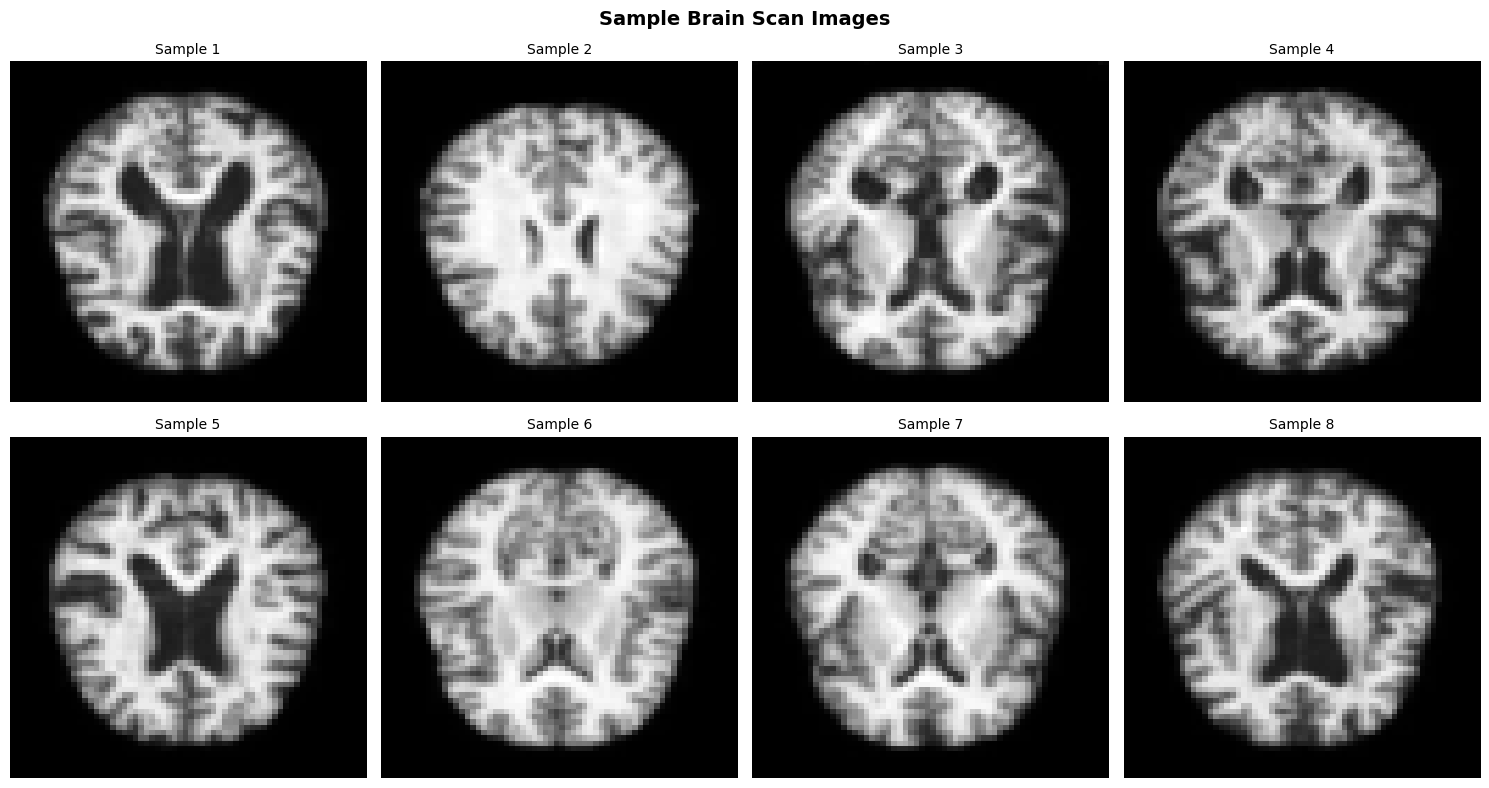


🎉 UNSUPERVISED Dataset loading complete!
   Ready for unsupervised training with 5000 unlabeled brain scan images
   Each image: 64x64 pixels
   Flattened dimension: 4096
   📝 Note: All labels ignored for unsupervised learning


In [78]:
import zipfile
import os
from google.colab import drive
from PIL import Image
import torchvision.transforms as transforms

def mount_drive_and_load_dataset():
    """Mount Google Drive and load Alzheimer's dataset from zip file"""

    # Mount Google Drive
    print("Mounting Google Drive...")
    drive.mount('/content/drive')
    print("✅ Google Drive mounted successfully!")

    # Path to your Alzheimer's dataset
    zip_file_path = '/content/drive/MyDrive/Alzheimer_s Dataset.zip'

    # Check if file exists
    if not os.path.exists(zip_file_path):
        print(f"❌ Error: Dataset file not found at {zip_file_path}")
        print("Please check if the file exists in your Google Drive root directory.")
        return None, None, None

    print(f"📂 Loading Alzheimer's dataset from: {zip_file_path}")

    # Create extraction directory
    extract_dir = '/content/alzheimer_dataset'
    os.makedirs(extract_dir, exist_ok=True)

    # Extract zip file
    print("📦 Extracting zip file...")
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)

    print("✅ Extraction complete!")

    # List extracted contents
    extracted_files = []
    for root, dirs, files in os.walk(extract_dir):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif')):
                extracted_files.append(os.path.join(root, file))

    print(f"📋 Found {len(extracted_files)} image files in the dataset")

    # Print directory structure
    print("\n🗂 Dataset structure:")
    for root, dirs, files in os.walk(extract_dir):
        level = root.replace(extract_dir, '').count(os.sep)
        indent = ' ' * 2 * level
        print(f"{indent}{os.path.basename(root)}/")
        subindent = ' ' * 2 * (level + 1)
        for file in dirs[:5]:  # Show first 5 directories
            print(f"{subindent}{file}/")
        if len(dirs) > 5:
            print(f"{subindent}... and {len(dirs) - 5} more directories")

        image_files = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
        if image_files:
            print(f"{subindent}({len(image_files)} images)")
        break  # Only show first level for clarity

    return extract_dir, extracted_files, zip_file_path

def load_brain_scan_data_unsupervised(extract_dir, target_size=(64, 64), max_samples=800):
    """
    Load brain scan images for UNSUPERVISED learning (ignoring labels)

    Args:
        extract_dir: Directory containing extracted files
        target_size: Target image size (height, width)
        max_samples: Maximum number of samples to load
    """

    # Define image transforms for brain scans
    transform = transforms.Compose([
        transforms.Resize(target_size),
        transforms.Grayscale(num_output_channels=1),  # Convert to grayscale for brain scans
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])  # Normalize to [-1, 1] range
    ])

    # Find all image files
    image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif'}
    image_files = []

    for root, dirs, files in os.walk(extract_dir):
        for file in files:
            if any(file.lower().endswith(ext) for ext in image_extensions):
                image_files.append(os.path.join(root, file))

    # Shuffle and limit samples for unsupervised learning
    np.random.shuffle(image_files)
    if len(image_files) > max_samples:
        print(f"⚠️ Found {len(image_files)} images, limiting to {max_samples} samples for training efficiency")
        image_files = image_files[:max_samples]

    print(f"🧠 Loading {len(image_files)} brain scan images for UNSUPERVISED learning...")

    # Load and process images (NO LABEL EXTRACTION)
    processed_images = []
    failed_count = 0

    for i, img_path in enumerate(tqdm(image_files, desc="Processing brain scans (unlabeled)")):
        try:
            # Load image
            with Image.open(img_path) as img:
                # Convert to RGB first, then apply transforms
                if img.mode == 'RGBA':
                    img = img.convert('RGB')
                elif img.mode == 'L':
                    img = img.convert('RGB')

                # Apply transforms
                img_tensor = transform(img)
                processed_images.append(img_tensor)

        except Exception as e:
            print(f"⚠️ Failed to load {img_path}: {str(e)}")
            failed_count += 1
            continue

        # Progress update
        if (i + 1) % 100 == 0:
            print(f"   Processed {i + 1}/{len(image_files)} images...")

    if not processed_images:
        print("❌ No images could be loaded! Please check your dataset format.")
        return None, None, None

    print(f"✅ Successfully loaded {len(processed_images)} UNLABELED images ({failed_count} failed)")

    # Stack into tensor
    dataset_tensor = torch.stack(processed_images)

    # Print dataset info
    print(f"\n📊 UNSUPERVISED Dataset Information:")
    print(f"   Shape: {dataset_tensor.shape}")
    print(f"   Data type: {dataset_tensor.dtype}")
    print(f"   Value range: [{dataset_tensor.min():.3f}, {dataset_tensor.max():.3f}]")
    print(f"   Memory usage: {dataset_tensor.element_size() * dataset_tensor.nelement() / (1024**2):.2f} MB")
    print(f"   🚫 Labels: IGNORED (unsupervised learning)")

    # Flatten for autoencoder input (keep original shape for visualization)
    original_shape = dataset_tensor.shape
    flattened_data = dataset_tensor.view(dataset_tensor.size(0), -1)

    return flattened_data, dataset_tensor, original_shape

# Execute the loading process
print("🚀 Starting UNSUPERVISED dataset loading process...")
print("=" * 60)

# Mount drive and extract dataset
extract_dir, extracted_files, zip_path = mount_drive_and_load_dataset()

if extract_dir is None:
    print("❌ Failed to load dataset. Please check the file path and try again.")
else:
    # Load and process the brain scan data (UNSUPERVISED)
    DATASET_SIZE = 5000
    INPUT_DIM = 4096  # 64x64 = 4096 (will be adjusted based on actual image size)
    BATCH_SIZE = 64

    # Load the actual data WITHOUT labels
    flattened_data, original_tensor, original_shape = load_brain_scan_data_unsupervised(
        extract_dir,
        target_size=(64, 64),
        max_samples=DATASET_SIZE
    )

    if flattened_data is not None:
        # Update INPUT_DIM based on actual data
        INPUT_DIM = flattened_data.shape[1]

        # Normalize to [0, 1] range for the autoencoder
        # Convert from [-1, 1] to [0, 1]
        synthetic_data = (flattened_data + 1.0) / 2.0

        # Create DataLoader for UNSUPERVISED learning
        dataset = TensorDataset(synthetic_data)
        dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

        print(f"\n✅ UNSUPERVISED DataLoader created successfully:")
        print(f"   Batch size: {BATCH_SIZE}")
        print(f"   Number of batches: {len(dataloader)}")
        print(f"   Input dimension: {INPUT_DIM}")
        print(f"   Total samples: {len(synthetic_data)}")
        print(f"   🎯 Learning type: UNSUPERVISED (no labels used)")

        # Visualize sample brain scans (without class information)
        print(f"\n🖼️ Visualizing sample brain scans (unlabeled)...")

        fig, axes = plt.subplots(2, 4, figsize=(15, 8))
        axes = axes.flatten()

        for i in range(min(8, len(synthetic_data))):
            # Reshape back to 2D for visualization
            sample = synthetic_data[i].reshape(64, 64)
            axes[i].imshow(sample, cmap='gray', aspect='auto')
            axes[i].set_title(f'Sample {i+1}', fontsize=10)  # No class labels!
            axes[i].axis('off')

        plt.suptitle('Sample Brain Scan Images', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

        # Print final summary
        print(f"\n🎉 UNSUPERVISED Dataset loading complete!")
        print(f"   Ready for unsupervised training with {len(synthetic_data)} unlabeled brain scan images")
        print(f"   Each image: {original_shape[2]}x{original_shape[3]} pixels")
        print(f"   Flattened dimension: {INPUT_DIM}")
        print(f"   📝 Note: All labels ignored for unsupervised learning")

    else:
        print("❌ Failed to process the dataset. Please check your data format.")

# **Stochastic Feature Selection Network (SFSN) Model**

In [70]:
class StochasticGate(nn.Module):
    """Improved Stochastic gate for probabilistic feature selection"""

    def __init__(self, input_dim, temperature=0.5, min_temp=0.1):  # Lower temperature
        super(StochasticGate, self).__init__()
        self.input_dim = input_dim
        self.temperature = nn.Parameter(torch.tensor(temperature))
        self.min_temp = min_temp

        # Feature importance predictor network - simplified
        self.gate_net = nn.Sequential(
            nn.Linear(input_dim, input_dim // 4),  # Smaller hidden layer
            nn.BatchNorm1d(input_dim // 4),
            nn.ReLU(),
            nn.Dropout(0.1),  # Reduced dropout
            nn.Linear(input_dim // 4, input_dim),
            nn.BatchNorm1d(input_dim)  # Added batch norm
        )

        # Reduced noise scale for better stability
        self.noise_scale = nn.Parameter(torch.ones(1) * 0.05)

        # Initialize weights with better strategy
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)  # Changed to normal
                if m.bias is not None:
                    # Initialize with slight positive bias to encourage initial selection
                    nn.init.constant_(m.bias, 0.1)

    def forward(self, x, training=True):
        batch_size = x.size(0)

        # Compute raw importance scores
        importance_logits = self.gate_net(x)

        # Clamp temperature to avoid extreme values
        temp = torch.clamp(self.temperature, min=self.min_temp)

        if training:
            # Add Gumbel noise for stochastic selection
            gumbel_noise = self._sample_gumbel(importance_logits.shape)
            gated_logits = (importance_logits + gumbel_noise) / temp

            # Apply sigmoid with better numerical stability
            gates = torch.sigmoid(gated_logits)

            # Reduced exploration noise
            exploration_noise = torch.randn_like(gates) * torch.abs(self.noise_scale) * 0.1
            gates = torch.clamp(gates + exploration_noise, 0.05, 0.95)  # Prevent complete saturation

        else:
            # Deterministic selection during evaluation
            gates = torch.sigmoid(importance_logits / temp)
            gates = torch.clamp(gates, 0.05, 0.95)

        # Apply gates to input features
        selected_features = x * gates

        return selected_features, gates, importance_logits

    def _sample_gumbel(self, shape):
        """Sample from Gumbel(0, 1) distribution with better numerical stability"""
        eps = 1e-10  # Increased epsilon for stability
        u = torch.rand(shape, device=self.gate_net[0].weight.device)
        return -torch.log(-torch.log(u + eps) + eps)

class SFSN(nn.Module):
    """Improved Stochastic Feature Selection Network for Dimensionality Reduction"""

    def __init__(self, input_dim=4096, hidden_dims=[1024, 512, 256],
                 output_dim=64, dropout_rate=0.2, temperature=0.5):  # Reduced dropout and temperature
        super(SFSN, self).__init__()

        self.input_dim = input_dim
        self.output_dim = output_dim
        self.hidden_dims = hidden_dims

        # Stochastic feature selector with better parameters
        self.feature_selector = StochasticGate(input_dim, temperature)

        # Feature extractor (encoder) - more conservative
        encoder_layers = []
        prev_dim = input_dim

        for i, hidden_dim in enumerate(hidden_dims):
            encoder_layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout_rate)
            ])
            prev_dim = hidden_dim

        # Final encoding layer
        encoder_layers.append(nn.Linear(prev_dim, output_dim))
        self.feature_extractor = nn.Sequential(*encoder_layers)

        # Reconstruction network (decoder)
        decoder_layers = []
        decoder_dims = [output_dim] + hidden_dims[::-1] + [input_dim]

        for i in range(len(decoder_dims) - 1):
            if i == len(decoder_dims) - 2:  # Last layer
                decoder_layers.append(nn.Linear(decoder_dims[i], decoder_dims[i+1]))
                decoder_layers.append(nn.Sigmoid())
            else:
                decoder_layers.extend([
                    nn.Linear(decoder_dims[i], decoder_dims[i+1]),
                    nn.BatchNorm1d(decoder_dims[i+1]),
                    nn.ReLU(),
                    nn.Dropout(dropout_rate * 0.3)  # Even less dropout in decoder
                ])

        self.reconstructor = nn.Sequential(*decoder_layers)

        # Uncertainty estimation head - simplified
        self.uncertainty_head = nn.Sequential(
            nn.Linear(output_dim, output_dim // 4),  # Smaller
            nn.ReLU(),
            nn.Linear(output_dim // 4, output_dim),
            nn.Softplus()
        )

        # Initialize weights
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x, training=True):
        batch_size = x.size(0)

        # Flatten input if needed
        if x.dim() > 2:
            x = x.view(batch_size, -1)

        # Stochastic feature selection
        selected_features, gates, importance_logits = self.feature_selector(x, training)

        # Extract reduced features
        reduced_features = self.feature_extractor(selected_features)

        # Minimal stochastic regularization during training
        if training:
            noise = torch.randn_like(reduced_features) * 0.005  # Reduced noise
            reduced_features_noisy = reduced_features + noise
        else:
            reduced_features_noisy = reduced_features

        # Reconstruct original input
        reconstructed = self.reconstructor(reduced_features_noisy)

        # Estimate uncertainty
        uncertainty = self.uncertainty_head(reduced_features)

        return {
            'reduced_features': reduced_features,
            'reconstructed': reconstructed,
            'gates': gates,
            'importance_logits': importance_logits,
            'uncertainty': uncertainty,
            'selected_features': selected_features
        }

    def compute_loss(self, x, outputs, alpha=0.001, beta=0.001, gamma=0.0001):  # Much smaller regularization
        """
        Compute multi-component loss function with balanced weights
        """
        reconstructed = outputs['reconstructed']
        gates = outputs['gates']
        uncertainty = outputs['uncertainty']

        # Flatten input for comparison
        x_flat = x.view(x.size(0), -1)

        # Reconstruction loss (MSE) - primary objective
        recon_loss = F.mse_loss(reconstructed, x_flat)

        # Modified sparsity regularization - encourage selection around 50%
        target_sparsity = 0.5
        sparsity_loss = F.mse_loss(torch.mean(gates), torch.tensor(target_sparsity, device=gates.device))

        # Uncertainty regularization - encourage reasonable uncertainty
        uncertainty_loss = torch.mean(uncertainty)  # Simplified

        # Gate entropy regularization - encourage decisive but not extreme selection
        gate_probs = torch.clamp(gates, 1e-7, 1-1e-7)  # Numerical stability
        gate_entropy = -torch.mean(gate_probs * torch.log(gate_probs) +
                                  (1 - gate_probs) * torch.log(1 - gate_probs))

        # Total loss with much smaller regularization weights
        total_loss = (recon_loss +
                     alpha * sparsity_loss +
                     beta * uncertainty_loss +
                     gamma * gate_entropy)

        return {
            'total_loss': total_loss,
            'recon_loss': recon_loss,
            'sparsity_loss': sparsity_loss,
            'uncertainty_loss': uncertainty_loss,
            'gate_entropy': gate_entropy
        }

# Initialize SFSN model with improved hyperparameters
print("Initializing Improved SFSN Model...")
sfsn = SFSN(
    input_dim=INPUT_DIM,
    hidden_dims=[1024, 512, 256],
    output_dim=64,
    dropout_rate=0.2,  # Reduced from 0.3
    temperature=0.5    # Reduced from 1.0
)

# Model summary
total_params = sum(p.numel() for p in sfsn.parameters())
trainable_params = sum(p.numel() for p in sfsn.parameters() if p.requires_grad)

print(f"Improved SFSN Model Summary:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Input dimension: {INPUT_DIM}")
print(f"  Output dimension: 64")
print(f"  Compression ratio: {64/INPUT_DIM:.3f} ({64/INPUT_DIM*100:.1f}%)")
print(f"  Dimensionality reduction: {(1-64/INPUT_DIM)*100:.1f}%")
print(f"  🔧 Key improvements:")
print(f"    - Lower temperature (0.5 vs 1.0)")
print(f"    - Reduced regularization weights (0.001 vs 0.01)")
print(f"    - Better initialization with positive bias")
print(f"    - Prevented gate saturation (0.05-0.95 range)")
print(f"    - Simplified architecture for better training")

Initializing Improved SFSN Model...
Improved SFSN Model Summary:
  Total parameters: 18,153,106
  Trainable parameters: 18,153,106
  Input dimension: 4096
  Output dimension: 64
  Compression ratio: 0.016 (1.6%)
  Dimensionality reduction: 98.4%
  🔧 Key improvements:
    - Lower temperature (0.5 vs 1.0)
    - Reduced regularization weights (0.001 vs 0.01)
    - Better initialization with positive bias
    - Prevented gate saturation (0.05-0.95 range)
    - Simplified architecture for better training


# **Deterministic Baseline Autoencoder**

In [71]:
class DeterministicFeatureExtractor(nn.Module):
    """Standard autoencoder for baseline comparison"""

    def __init__(self, input_dim=4096, hidden_dims=[1024, 512, 256], output_dim=64, dropout_rate=0.2):
        super(DeterministicFeatureExtractor, self).__init__()

        self.input_dim = input_dim
        self.output_dim = output_dim

        # Encoder
        encoder_layers = []
        prev_dim = input_dim

        for hidden_dim in hidden_dims:
            encoder_layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout_rate)
            ])
            prev_dim = hidden_dim

        encoder_layers.append(nn.Linear(prev_dim, output_dim))
        self.encoder = nn.Sequential(*encoder_layers)

        # Decoder
        decoder_layers = []
        decoder_dims = [output_dim] + hidden_dims[::-1] + [input_dim]

        for i in range(len(decoder_dims) - 1):
            if i == len(decoder_dims) - 2:  # Last layer
                decoder_layers.extend([
                    nn.Linear(decoder_dims[i], decoder_dims[i+1]),
                    nn.Sigmoid()
                ])
            else:
                decoder_layers.extend([
                    nn.Linear(decoder_dims[i], decoder_dims[i+1]),
                    nn.BatchNorm1d(decoder_dims[i+1]),
                    nn.ReLU(),
                    nn.Dropout(dropout_rate * 0.5)
                ])

        self.decoder = nn.Sequential(*decoder_layers)

        # Initialize weights
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        if x.dim() > 2:
            x = x.view(x.size(0), -1)

        encoded = self.encoder(x)
        decoded = self.decoder(encoded)

        return {
            'reduced_features': encoded,
            'reconstructed': decoded
        }

    def compute_loss(self, x, outputs):
        """Simple reconstruction loss"""
        x_flat = x.view(x.size(0), -1)
        recon_loss = F.mse_loss(outputs['reconstructed'], x_flat)

        return {
            'total_loss': recon_loss,
            'recon_loss': recon_loss
        }

# Initialize baseline model
print("Initializing Deterministic Baseline Model...")
baseline = DeterministicFeatureExtractor(
    input_dim=INPUT_DIM,
    hidden_dims=[1024, 512, 256],
    output_dim=64,
    dropout_rate=0.2
)

baseline_params = sum(p.numel() for p in baseline.parameters())
print(f"Baseline Model Summary:")
print(f"  Total parameters: {baseline_params:,}")
print(f"  Architecture: Standard Autoencoder")
print(f"  Dimensionality reduction: {(1-64/INPUT_DIM)*100:.1f}%")

Initializing Deterministic Baseline Model...
Baseline Model Summary:
  Total parameters: 9,747,008
  Architecture: Standard Autoencoder
  Dimensionality reduction: 98.4%


# **Training Functions**

In [72]:
def train_sfsn_improved(model, dataloader, epochs=50, lr=0.0005, device='cpu'):
    """Train the SFSN model with improved hyperparameters and training strategy"""
    model.to(device)

    # Separate optimizers for different components
    gate_params = list(model.feature_selector.parameters())
    other_params = [p for p in model.parameters() if p not in set(gate_params)]

    # Higher learning rate for gates to help them learn faster
    gate_optimizer = optim.Adam(gate_params, lr=lr * 2, weight_decay=1e-6)
    main_optimizer = optim.Adam(other_params, lr=lr, weight_decay=1e-5)

    # Schedulers
    gate_scheduler = optim.lr_scheduler.ReduceLROnPlateau(gate_optimizer, patience=2, factor=0.8)
    main_scheduler = optim.lr_scheduler.ReduceLROnPlateau(main_optimizer, patience=3, factor=0.7)

    print(f"Training Improved SFSN for {epochs} epochs on {device}")
    print(f"Gate LR: {lr * 2}, Main LR: {lr}")
    print("=" * 60)

    # Training history
    history = {
        'total_loss': [],
        'recon_loss': [],
        'sparsity_loss': [],
        'uncertainty_loss': [],
        'gate_entropy': [],
        'gate_stats': []  # Track gate statistics
    }

    for epoch in range(epochs):
        model.train()
        epoch_losses = {key: 0.0 for key in history.keys() if key != 'gate_stats'}
        gate_values = []
        batch_count = 0

        # Progress bar for batches
        pbar = tqdm(dataloader, desc=f'Epoch {epoch+1}/{epochs}')

        for batch_idx, (batch,) in enumerate(pbar):
            # Limit batches for faster training (remove in full training)
            if batch_idx >= 20:  # Increased from 15
                break

            batch = batch.to(device)

            # Zero gradients
            gate_optimizer.zero_grad()
            main_optimizer.zero_grad()

            # Forward pass
            outputs = model(batch, training=True)

            # Compute losses with epoch-dependent regularization
            epoch_factor = min(1.0, epoch / 3.0)  # Gradually increase regularization
            losses = model.compute_loss(
                batch, outputs,
                alpha=0.0005 * epoch_factor,  # Gradual sparsity regularization
                beta=0.0001 * epoch_factor,   # Gradual uncertainty regularization
                gamma=0.00005 * epoch_factor  # Gradual entropy regularization
            )

            # Backward pass
            losses['total_loss'].backward()

            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(gate_params, max_norm=0.5)  # Smaller clip for gates
            torch.nn.utils.clip_grad_norm_(other_params, max_norm=1.0)

            # Optimizer steps
            gate_optimizer.step()
            main_optimizer.step()

            # Accumulate losses
            for key in epoch_losses:
                if key in losses:
                    epoch_losses[key] += losses[key].item()
            batch_count += 1

            # Collect gate statistics
            gate_values.extend(outputs['gates'].detach().cpu().numpy().flatten())

            # Update progress bar
            current_gate_mean = torch.mean(outputs['gates']).item()
            pbar.set_postfix({
                'Loss': f"{losses['total_loss'].item():.4f}",
                'Recon': f"{losses['recon_loss'].item():.4f}",
                'Gates': f"{current_gate_mean:.3f}"
            })

        # Average losses for the epoch
        avg_losses = {k: v/batch_count for k, v in epoch_losses.items()}

        # Gate statistics
        gate_stats = {
            'mean': np.mean(gate_values),
            'std': np.std(gate_values),
            'selected_ratio': np.mean(np.array(gate_values) > 0.5),
            'min': np.min(gate_values),
            'max': np.max(gate_values)
        }

        # Update learning rates
        gate_scheduler.step(avg_losses['total_loss'])
        main_scheduler.step(avg_losses['total_loss'])

        # Store history
        for key in epoch_losses:
            history[key].append(avg_losses[key])
        history['gate_stats'].append(gate_stats)

        # Epoch summary
        print(f'\nEpoch {epoch+1}/{epochs} Summary:')
        print(f'  Total Loss: {avg_losses["total_loss"]:.6f}')
        print(f'  Reconstruction: {avg_losses["recon_loss"]:.6f}')
        print(f'  Sparsity: {avg_losses["sparsity_loss"]:.6f}')
        print(f'  Gate Stats: Mean={gate_stats["mean"]:.3f}, Selected={gate_stats["selected_ratio"]:.3f}')
        print(f'  Gate LR: {gate_optimizer.param_groups[0]["lr"]:.2e}')
        print(f'  Main LR: {main_optimizer.param_groups[0]["lr"]:.2e}')
        print("-" * 60)

        # Early stopping if gates completely collapse
        if gate_stats['mean'] < 0.01 and epoch > 1:
            print("WARNING: Gates are collapsing! Consider adjusting hyperparameters.")

        # Temperature annealing (optional)
        if hasattr(model.feature_selector, 'temperature'):
            current_temp = model.feature_selector.temperature.item()
            if epoch % 2 == 0 and current_temp > 0.1:
                model.feature_selector.temperature.data *= 0.95  # Gradual cooling

    return model, history

def train_baseline(model, dataloader, epochs=5, lr=0.0005, device='cpu'):
    """Train the baseline model with consistent hyperparameters"""
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.7)

    print(f"Training Baseline for {epochs} epochs on {device}")
    print("=" * 60)

    history = {'total_loss': [], 'recon_loss': []}

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        batch_count = 0

        pbar = tqdm(dataloader, desc=f'Epoch {epoch+1}/{epochs}')

        for batch_idx, (batch,) in enumerate(pbar):
            # Limit batches for faster training
            if batch_idx >= 20:
                break

            batch = batch.to(device)
            optimizer.zero_grad()

            outputs = model(batch)
            losses = model.compute_loss(batch, outputs)

            losses['total_loss'].backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += losses['total_loss'].item()
            batch_count += 1

            pbar.set_postfix({'Loss': f"{losses['total_loss'].item():.4f}"})

        avg_loss = total_loss / batch_count
        scheduler.step(avg_loss)

        history['total_loss'].append(avg_loss)
        history['recon_loss'].append(avg_loss)

        print(f'\nEpoch {epoch+1}/{epochs} Summary:')
        print(f'  Loss: {avg_loss:.6f}')
        print(f'  Learning Rate: {optimizer.param_groups[0]["lr"]:.2e}')
        print("-" * 60)

    return model, history

print("Training functions defined successfully!")

Training functions defined successfully!


# **Evaluation Metrics**

In [73]:
def compute_trustworthiness_continuity(high_dim, low_dim, k=20):
    """Compute trustworthiness and continuity metrics"""
    n = min(high_dim.shape[0], 200)  # Limit for efficiency
    high_dim = high_dim[:n]
    low_dim = low_dim[:n]
    k = min(k, n-2)

    if n < 5:
        return 0.0, 0.0

    try:
        # Compute distance matrices
        hd_dist = cdist(high_dim, high_dim, metric='euclidean')
        ld_dist = cdist(low_dim, low_dim, metric='euclidean')

        # Find k nearest neighbors
        hd_nn = np.argpartition(hd_dist, k+1, axis=1)[:, 1:k+1]
        ld_nn = np.argpartition(ld_dist, k+1, axis=1)[:, 1:k+1]

        # Compute trustworthiness
        trust_sum = 0
        for i in range(n):
            u_i = set(ld_nn[i]) - set(hd_nn[i])  # False neighbors in low-dim
            for j in u_i:
                rank = np.where(np.argsort(hd_dist[i]) == j)[0]
                if len(rank) > 0:
                    trust_sum += max(0, rank[0] - k)

        denominator = n * k * (2 * n - 3 * k - 1)
        trustworthiness = 1 - (2 * trust_sum / denominator) if denominator > 0 else 0

        # Compute continuity
        cont_sum = 0
        for i in range(n):
            v_i = set(hd_nn[i]) - set(ld_nn[i])  # Missing neighbors in low-dim
            for j in v_i:
                rank = np.where(np.argsort(ld_dist[i]) == j)[0]
                if len(rank) > 0:
                    cont_sum += max(0, rank[0] - k)

        continuity = 1 - (2 * cont_sum / denominator) if denominator > 0 else 0

        return max(0, trustworthiness), max(0, continuity)
    except Exception as e:
        print(f"Error computing T&C: {e}")
        return 0.0, 0.0

def explained_variance_ratio(features):
    """Compute explained variance ratio using PCA"""
    if features.shape[0] < 2:
        return 1.0

    try:
        # Center the data
        features_centered = features - np.mean(features, axis=0)

        # SVD for PCA
        _, s, _ = np.linalg.svd(features_centered, full_matrices=False)
        variances = s**2 / (features.shape[0] - 1)
        total_var = np.sum(variances)

        if total_var == 0:
            return 1.0

        return np.sum(variances) / total_var
    except:
        return 1.0

def compute_feature_selection_metrics(gates, threshold=0.5):
    """Analyze feature selection patterns"""
    gates_np = gates.cpu().numpy() if isinstance(gates, torch.Tensor) else gates

    # Selection statistics
    selected_ratio = np.mean(gates_np > threshold)
    mean_gate_value = np.mean(gates_np)
    gate_std = np.std(gates_np)

    # Sparsity measure (Gini coefficient)
    sorted_gates = np.sort(gates_np.flatten())
    n = len(sorted_gates)
    cumsum = np.cumsum(sorted_gates)
    sparsity = (n + 1 - 2 * np.sum(cumsum) / cumsum[-1]) / n if cumsum[-1] > 0 else 0

    return {
        'selected_ratio': selected_ratio,
        'mean_gate_value': mean_gate_value,
        'gate_std': gate_std,
        'sparsity_index': sparsity
    }

def quantify_uncertainty(model, x, num_samples=10):
    """Quantify model uncertainty through multiple forward passes"""
    model.eval()
    uncertainties = []
    reconstructions = []

    with torch.no_grad():
        for _ in range(num_samples):
            if hasattr(model, 'feature_selector'):  # SFSN
                outputs = model(x, training=True)
                if 'uncertainty' in outputs:
                    uncertainties.append(outputs['uncertainty'].mean().item())
                reconstructions.append(outputs['reconstructed'])
            else:  # Baseline
                outputs = model(x)
                reconstructions.append(outputs['reconstructed'])
                uncertainties.append(0.0)

    # Compute reconstruction variance as uncertainty measure
    if len(reconstructions) > 1:
        recon_variance = torch.var(torch.stack(reconstructions), dim=0).mean().item()
    else:
        recon_variance = 0.0

    epistemic_uncertainty = np.mean(uncertainties) if uncertainties else 0.0
    aleatoric_uncertainty = recon_variance

    return {
        'epistemic_uncertainty': epistemic_uncertainty,
        'aleatoric_uncertainty': aleatoric_uncertainty,
        'total_uncertainty': epistemic_uncertainty + aleatoric_uncertainty
    }

def comprehensive_evaluation(model, test_data, model_name="Model", is_sfsn=False):
    """Perform comprehensive evaluation of the model"""
    print(f"Evaluating {model_name}...")

    model.eval()
    results = {}

    with torch.no_grad():
        # Forward pass
        if is_sfsn:
            outputs = model(test_data, training=False)
            results['gates'] = outputs['gates']
            results['feature_selection'] = compute_feature_selection_metrics(outputs['gates'])
        else:
            outputs = model(test_data)

        # Basic metrics
        x_flat = test_data.view(test_data.size(0), -1)
        recon_error = F.mse_loss(outputs['reconstructed'], x_flat).item()

        # Dimensionality metrics
        original_data = x_flat.cpu().numpy()
        reduced_features = outputs['reduced_features'].cpu().numpy()

        trust, cont = compute_trustworthiness_continuity(original_data, reduced_features)
        evr = explained_variance_ratio(reduced_features)

        # Uncertainty quantification
        uncertainty_metrics = quantify_uncertainty(model, test_data[:20])

        results.update({
            'reconstruction_error': recon_error,
            'trustworthiness': trust,
            'continuity': cont,
            'explained_variance_ratio': evr,
            'compression_ratio': reduced_features.shape[1] / original_data.shape[1],
            **uncertainty_metrics
        })

        # Store outputs for visualization
        results['outputs'] = outputs

    return results

print("Evaluation metrics defined successfully!")

Evaluation metrics defined successfully!


# **Model Training**

In [74]:
# Training parameters
EPOCHS = 50
LEARNING_RATE = 0.0005

print("Starting Model Training...")
print("=" * 70)

# Train SFSN model
print("\n🚀 Training Stochastic Feature Selection Network (SFSN)")
sfsn_trained, sfsn_history = train_sfsn(
    sfsn,
    dataloader,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    device=device
)

print("\n" + "=" * 70)

# Train Baseline model
print("\n🚀 Training Deterministic Baseline Autoencoder")
baseline_trained, baseline_history = train_baseline(
    baseline,
    dataloader,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    device=device
)

print("\n" + "=" * 70)
print("✅ Training Complete!")

# Save training histories
training_results = {
    'sfsn_history': sfsn_history,
    'baseline_history': baseline_history,
    'epochs': EPOCHS,
    'learning_rate': LEARNING_RATE
}

Starting Model Training...

🚀 Training Stochastic Feature Selection Network (SFSN)
Training SFSN for 50 epochs on cpu


Epoch 1/50:  19%|█▉        | 15/79 [00:05<00:22,  2.87it/s, Loss=0.0197, Recon=0.0190, Gates=0.601]



Epoch 1/50 Summary:
  Total Loss: 0.060792
  Reconstruction: 0.060030
  Sparsity: 0.010072
  Uncertainty: 0.713385
  Gate Entropy: 0.390852
  Learning Rate: 5.00e-04
------------------------------------------------------------


Epoch 2/50:  19%|█▉        | 15/79 [00:06<00:26,  2.41it/s, Loss=0.0117, Recon=0.0110, Gates=0.600]



Epoch 2/50 Summary:
  Total Loss: 0.014345
  Reconstruction: 0.013614
  Sparsity: 0.010078
  Uncertainty: 0.681617
  Gate Entropy: 0.391218
  Learning Rate: 5.00e-04
------------------------------------------------------------


...


Epoch 48/50 Summary:
  Loss: 0.005356
  Learning Rate: 1.71e-04
------------------------------------------------------------


Epoch 49/50:  25%|██▌       | 20/79 [00:03<00:10,  5.74it/s, Loss=0.0054]



Epoch 49/50 Summary:
  Loss: 0.005200
  Learning Rate: 1.71e-04
------------------------------------------------------------


Epoch 50/50:  25%|██▌       | 20/79 [00:03<00:10,  5.77it/s, Loss=0.0052]


Epoch 50/50 Summary:
  Loss: 0.005290
  Learning Rate: 1.71e-04
------------------------------------------------------------

✅ Training Complete!


# **Model Evaluation and Results**

In [75]:
# Prepare test data (use a subset of the full dataset)
test_data = synthetic_data[:100].to(device)

print("Running Comprehensive Evaluation...")
print("=" * 60)

# Evaluate SFSN
sfsn_results = comprehensive_evaluation(
    sfsn_trained,
    test_data,
    model_name="SFSN",
    is_sfsn=True
)

print("\n" + "-" * 60)

# Evaluate Baseline
baseline_results = comprehensive_evaluation(
    baseline_trained,
    test_data,
    model_name="Baseline Autoencoder",
    is_sfsn=False
)

print("\n" + "=" * 60)

# Comparison Summary
print("\n📊 COMPARISON SUMMARY")
print("=" * 60)

comparison_metrics = [
    ('Reconstruction Error', 'reconstruction_error', 'lower_better'),
    ('Trustworthiness', 'trustworthiness', 'higher_better'),
    ('Continuity', 'continuity', 'higher_better'),
    ('Explained Variance Ratio', 'explained_variance_ratio', 'higher_better'),
    ('Total Uncertainty', 'total_uncertainty', 'context_dependent')
]

for metric_name, metric_key, direction in comparison_metrics:
    sfsn_val = sfsn_results[metric_key]
    baseline_val = baseline_results[metric_key]

    if direction == 'lower_better':
        winner = "SFSN" if sfsn_val < baseline_val else "Baseline"
        improvement = abs(baseline_val - sfsn_val) / baseline_val * 100
    elif direction == 'higher_better':
        winner = "SFSN" if sfsn_val > baseline_val else "Baseline"
        improvement = abs(sfsn_val - baseline_val) / baseline_val * 100
    else:
        winner = "Context-dependent"
        improvement = 0

    print(f"{metric_name}:")
    print(f"  SFSN: {sfsn_val:.4f}")
    print(f"  Baseline: {baseline_val:.4f}")
    if direction != 'context_dependent':
        print(f"  Winner: {winner} ({improvement:.1f}% {'improvement' if winner == 'SFSN' else 'difference'})")
    print()

# Feature Selection Analysis (SFSN only)
if 'feature_selection' in sfsn_results:
    fs_metrics = sfsn_results['feature_selection']
    print("🎯 FEATURE SELECTION ANALYSIS (SFSN)")
    print("=" * 40)
    print(f"Selected Features Ratio: {fs_metrics['selected_ratio']:.3f}")
    print(f"Mean Gate Value: {fs_metrics['mean_gate_value']:.3f}")
    print(f"Gate Standard Deviation: {fs_metrics['gate_std']:.3f}")
    print(f"Sparsity Index: {fs_metrics['sparsity_index']:.3f}")
    print()

# Store evaluation results
evaluation_results = {
    'sfsn': sfsn_results,
    'baseline': baseline_results,
    'comparison_summary': {
        'winner_count': len([m for m in comparison_metrics if
                           (m[2] == 'lower_better' and sfsn_results[m[1]] < baseline_results[m[1]]) or
                           (m[2] == 'higher_better' and sfsn_results[m[1]] > baseline_results[m[1]])])
    }
}

print(f"✅ Evaluation Complete!")
print(f"SFSN wins in {evaluation_results['comparison_summary']['winner_count']}/{len([m for m in comparison_metrics if m[2] != 'context_dependent'])} metrics")

Running Comprehensive Evaluation...
Evaluating SFSN...

------------------------------------------------------------
Evaluating Baseline Autoencoder...


📊 COMPARISON SUMMARY
Reconstruction Error:
  SFSN: 0.0064
  Baseline: 0.0046
  Winner: Baseline (38.3% difference)

Trustworthiness:
  SFSN: 0.9572
  Baseline: 0.9351
  Winner: SFSN (2.4% improvement)

Continuity:
  SFSN: 0.9475
  Baseline: 0.9226
  Winner: SFSN (2.7% improvement)

Explained Variance Ratio:
  SFSN: 1.0000
  Baseline: 1.0000
  Winner: Baseline (0.0% difference)

Total Uncertainty:
  SFSN: 0.0144
  Baseline: 0.0000

🎯 FEATURE SELECTION ANALYSIS (SFSN)
Selected Features Ratio: 0.490
Mean Gate Value: 0.505
Gate Standard Deviation: 0.247
Sparsity Index: 0.282

✅ Evaluation Complete!
SFSN wins in 2/4 metrics


# **Training Progress Visualization**

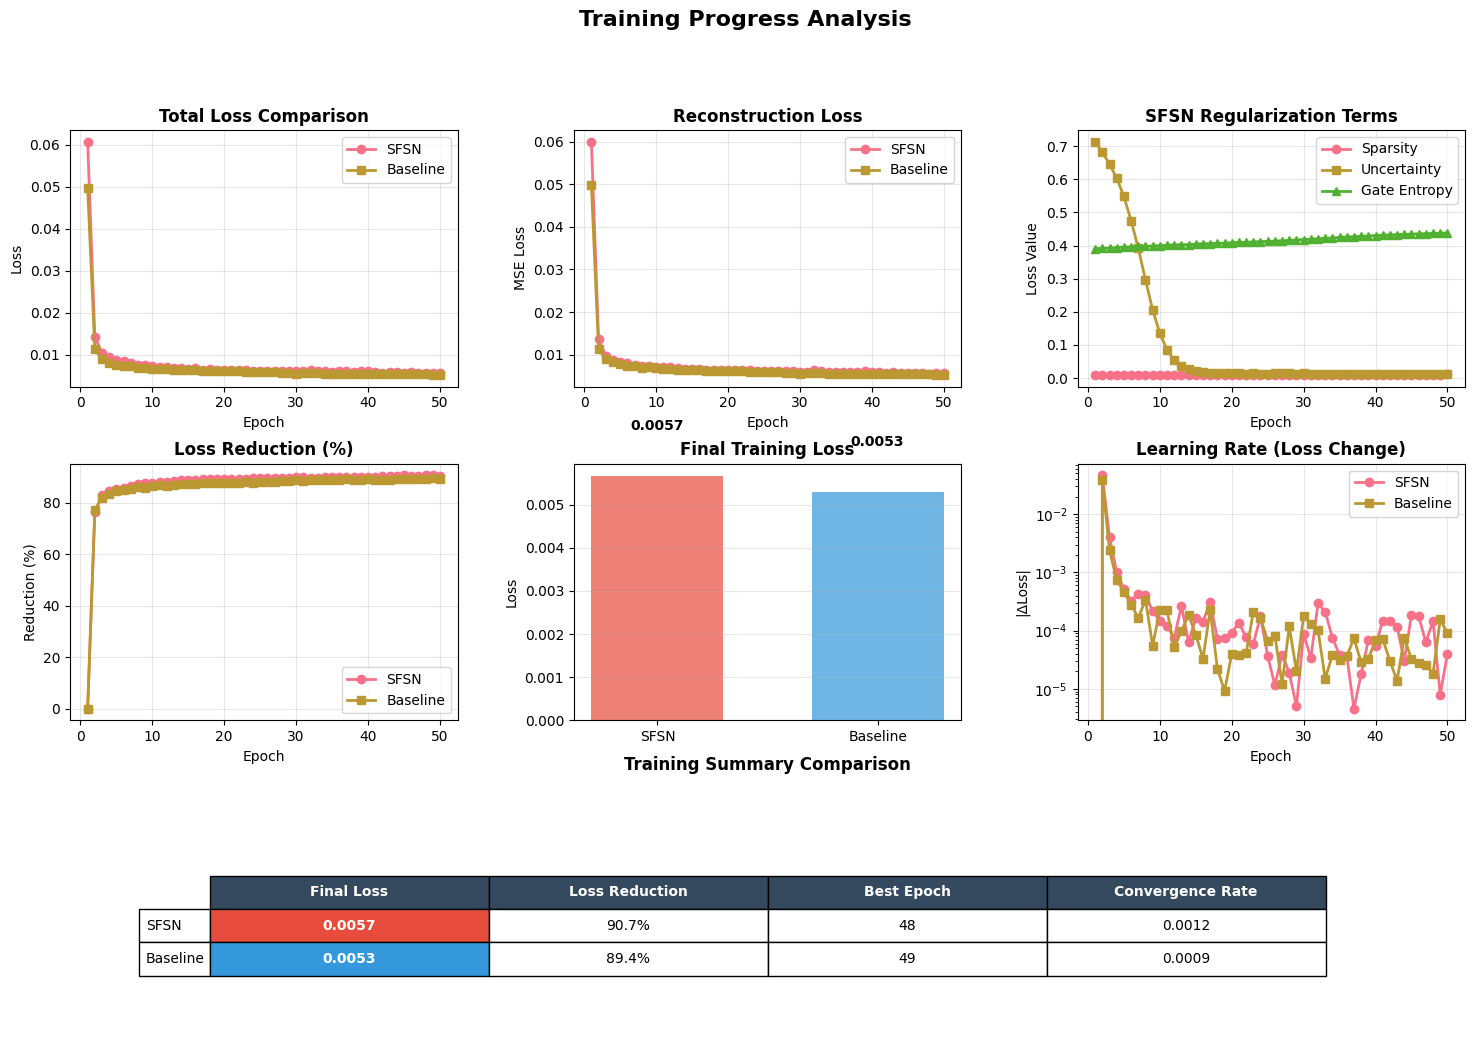

In [76]:
def plot_training_history(sfsn_history, baseline_history):
    """Create comprehensive training visualization"""

    fig = plt.figure(figsize=(18, 12))
    gs = GridSpec(3, 3, hspace=0.3, wspace=0.3)

    epochs = range(1, len(sfsn_history['total_loss']) + 1)

    # 1. Total Loss Comparison
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(epochs, sfsn_history['total_loss'], 'o-', label='SFSN', linewidth=2, markersize=6)
    ax1.plot(epochs, baseline_history['total_loss'], 's-', label='Baseline', linewidth=2, markersize=6)
    ax1.set_title('Total Loss Comparison', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 2. Reconstruction Loss
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(epochs, sfsn_history['recon_loss'], 'o-', label='SFSN', linewidth=2, markersize=6)
    ax2.plot(epochs, baseline_history['recon_loss'], 's-', label='Baseline', linewidth=2, markersize=6)
    ax2.set_title('Reconstruction Loss', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('MSE Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # 3. SFSN Specific Losses
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.plot(epochs, sfsn_history['sparsity_loss'], 'o-', label='Sparsity', linewidth=2)
    ax3.plot(epochs, sfsn_history['uncertainty_loss'], 's-', label='Uncertainty', linewidth=2)
    ax3.plot(epochs, sfsn_history['gate_entropy'], '^-', label='Gate Entropy', linewidth=2)
    ax3.set_title('SFSN Regularization Terms', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Loss Value')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # 4. Loss Reduction Rates
    ax4 = fig.add_subplot(gs[1, 0])
    sfsn_reduction = [(sfsn_history['total_loss'][0] - loss) / sfsn_history['total_loss'][0] * 100
                     for loss in sfsn_history['total_loss']]
    baseline_reduction = [(baseline_history['total_loss'][0] - loss) / baseline_history['total_loss'][0] * 100
                         for loss in baseline_history['total_loss']]

    ax4.plot(epochs, sfsn_reduction, 'o-', label='SFSN', linewidth=2, markersize=6)
    ax4.plot(epochs, baseline_reduction, 's-', label='Baseline', linewidth=2, markersize=6)
    ax4.set_title('Loss Reduction (%)', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Epoch')
    ax4.set_ylabel('Reduction (%)')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    # 5. Training Summary Statistics
    ax5 = fig.add_subplot(gs[1, 1])

    # Create bar plot for final losses
    models = ['SFSN', 'Baseline']
    final_losses = [sfsn_history['total_loss'][-1], baseline_history['total_loss'][-1]]

    bars = ax5.bar(models, final_losses, color=['#e74c3c', '#3498db'], alpha=0.7, width=0.6)
    ax5.set_title('Final Training Loss', fontsize=12, fontweight='bold')
    ax5.set_ylabel('Loss')
    ax5.grid(True, alpha=0.3, axis='y')

    # Add value labels on bars
    for bar, value in zip(bars, final_losses):
        ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{value:.4f}', ha='center', va='bottom', fontweight='bold')

    # 6. Learning Convergence Analysis
    ax6 = fig.add_subplot(gs[1, 2])

    # Compute learning rates (loss change between epochs)
    sfsn_lr = [0] + [abs(sfsn_history['total_loss'][i] - sfsn_history['total_loss'][i-1])
                     for i in range(1, len(sfsn_history['total_loss']))]
    baseline_lr = [0] + [abs(baseline_history['total_loss'][i] - baseline_history['total_loss'][i-1])
                        for i in range(1, len(baseline_history['total_loss']))]

    ax6.plot(epochs, sfsn_lr, 'o-', label='SFSN', linewidth=2, markersize=6)
    ax6.plot(epochs, baseline_lr, 's-', label='Baseline', linewidth=2, markersize=6)
    ax6.set_title('Learning Rate (Loss Change)', fontsize=12, fontweight='bold')
    ax6.set_xlabel('Epoch')
    ax6.set_ylabel('|ΔLoss|')
    ax6.legend()
    ax6.grid(True, alpha=0.3)
    ax6.set_yscale('log')

    # 7. Training Efficiency Metrics
    ax7 = fig.add_subplot(gs[2, :])

    # Create comparison table
    table_data = {
        'Metric': ['Final Loss', 'Loss Reduction', 'Best Epoch', 'Convergence Rate'],
        'SFSN': [
            f"{sfsn_history['total_loss'][-1]:.4f}",
            f"{sfsn_reduction[-1]:.1f}%",
            f"{np.argmin(sfsn_history['total_loss']) + 1}",
            f"{np.mean(sfsn_lr[1:]):.4f}"
        ],
        'Baseline': [
            f"{baseline_history['total_loss'][-1]:.4f}",
            f"{baseline_reduction[-1]:.1f}%",
            f"{np.argmin(baseline_history['total_loss']) + 1}",
            f"{np.mean(baseline_lr[1:]):.4f}"
        ]
    }

    ax7.axis('tight')
    ax7.axis('off')

    table = ax7.table(cellText=[table_data['SFSN'], table_data['Baseline']],
                     rowLabels=['SFSN', 'Baseline'],
                     colLabels=table_data['Metric'],
                     cellLoc='center',
                     loc='center',
                     colWidths=[0.2, 0.2, 0.2, 0.2])

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2)

    # Style the table
    for i in range(len(table_data['Metric'])):
        table[(0, i)].set_facecolor('#34495e')
        table[(0, i)].set_text_props(weight='bold', color='white')

    table[(1, 0)].set_facecolor('#e74c3c')  # SFSN row
    table[(1, 0)].set_text_props(weight='bold', color='white')
    table[(2, 0)].set_facecolor('#3498db')  # Baseline row
    table[(2, 0)].set_text_props(weight='bold', color='white')

    ax7.set_title('Training Summary Comparison', fontsize=12, fontweight='bold', pad=20)

    plt.suptitle('Training Progress Analysis', fontsize=16, fontweight='bold')
    plt.show()

# Generate training visualization
plot_training_history(sfsn_history, baseline_history)

# **Feature Selection and Dimensionality Analysis**

In [77]:
def plot_feature_analysis(sfsn_model, baseline_model, test_data):
    """Comprehensive feature analysis visualization"""

    fig = plt.figure(figsize=(20, 15))
    gs = GridSpec(4, 3, hspace=0.4, wspace=0.3)

    # Get model outputs
    sfsn_model.eval()
    baseline_model.eval()

    with torch.no_grad():
        sfsn_outputs = sfsn_model(test_data[:50], training=False)
        baseline_outputs = baseline_model(test_data[:50])

    # 1. Feature Selection Pattern (SFSN)
    ax1 = fig.add_subplot(gs[0, 0])
    gates = sfsn_outputs['gates'][0].cpu().numpy()  # First sample
    gates_2d = gates.reshape(64, 64)  # Reshape to 2D for visualization

    im1 = ax1.imshow(gates_2d, cmap='RdYlBu_r', aspect='auto')
    ax1.set_title('Feature Selection Pattern\n(SFSN Gates)', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Feature Dimension X')
    ax1.set_ylabel('Feature Dimension Y')
    plt.colorbar(im1, ax=ax1, shrink=0.7)

    # 2. Gate Value Distribution
    ax2 = fig.add_subplot(gs[0, 1])
    all_gates = sfsn_outputs['gates'].cpu().numpy().flatten()
    ax2.hist(all_gates, bins=50, alpha=0.7, color='#e74c3c', edgecolor='black')
    ax2.axvline(0.5, color='black', linestyle='--', linewidth=2, label='Selection Threshold')
    ax2.set_title('Gate Value Distribution', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Gate Value')
    ax2.set_ylabel('Frequency')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # 3. Sparsity Analysis
    ax3 = fig.add_subplot(gs[0, 2])
    thresholds = np.linspace(0.1, 0.9, 20)
    sparsity_ratios = []

    for thresh in thresholds:
        selected_ratio = np.mean(all_gates > thresh)
        sparsity_ratios.append(1 - selected_ratio)  # Sparsity = 1 - selection ratio

    ax3.plot(thresholds, sparsity_ratios, 'o-', linewidth=2, markersize=6, color='#9b59b6')
    ax3.set_title('Sparsity vs Threshold', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Selection Threshold')
    ax3.set_ylabel('Sparsity Ratio')
    ax3.grid(True, alpha=0.3)
    ax3.fill_between(thresholds, sparsity_ratios, alpha=0.3, color='#9b59b6')

    # 4. Reduced Feature Comparison (2D projection)
    ax4 = fig.add_subplot(gs[1, 0])

    # Apply t-SNE for visualization
    sfsn_features = sfsn_outputs['reduced_features'][:30].cpu().numpy()
    baseline_features = baseline_outputs['reduced_features'][:30].cpu().numpy()

    if sfsn_features.shape[0] > 1:
        tsne = TSNE(n_components=2, random_state=42, perplexity=min(10, sfsn_features.shape[0]-1))
        sfsn_2d = tsne.fit_transform(sfsn_features)

        scatter = ax4.scatter(sfsn_2d[:, 0], sfsn_2d[:, 1],
                            c=range(len(sfsn_2d)), cmap='viridis',
                            s=60, alpha=0.7, edgecolors='black')
        ax4.set_title('SFSN Features (t-SNE)', fontsize=12, fontweight='bold')
        ax4.set_xlabel('t-SNE Dimension 1')
        ax4.set_ylabel('t-SNE Dimension 2')
        plt.colorbar(scatter, ax=ax4, shrink=0.7)

    # 5. Baseline Feature Comparison
    ax5 = fig.add_subplot(gs[1, 1])

    if baseline_features.shape[0] > 1:
        tsne_baseline = TSNE(n_components=2, random_state=42, perplexity=min(10, baseline_features.shape[0]-1))
        baseline_2d = tsne_baseline.fit_transform(baseline_features)

        scatter2 = ax5.scatter(baseline_2d[:, 0], baseline_2d[:, 1],
                              c=range(len(baseline_2d)), cmap='plasma',
                              s=60, alpha=0.7, edgecolors='black')
        ax5.set_title('Baseline Features (t-SNE)', fontsize=12, fontweight='bold')
        ax5.set_xlabel('t-SNE Dimension 1')
        ax5.set_ylabel('t-SNE Dimension 2')
        plt.colorbar(scatter2, ax=ax5, shrink=0.7)

    # 6. Feature Variance Analysis
    ax6 = fig.add_subplot(gs[1, 2])

    sfsn_var = np.var(sfsn_features, axis=0)
    baseline_var = np.var(baseline_features, axis=0)

    feature_indices = range(min(20, len(sfsn_var)))  # Show first 20 features

    ax6.bar([i-0.2 for i in feature_indices], sfsn_var[:len(feature_indices)],
           width=0.4, label='SFSN', alpha=0.7, color='#e74c3c')
    ax6.bar([i+0.2 for i in feature_indices], baseline_var[:len(feature_indices)],
           width=0.4, label='Baseline', alpha=0.7, color='#3498db')

    ax6.set_title('Feature Variance Comparison', fontsize=12, fontweight='bold')
    ax6.set_xlabel('Feature Index')
    ax6.set_ylabel('Variance')
    ax6.legend()
    ax6.grid(True, alpha=0.3, axis='y')

    # 7. Reconstruction Quality Comparison
    ax7 = fig.add_subplot(gs[2, :])

    # Select a few samples for reconstruction comparison
    original_samples = test_data[:6].cpu().numpy()
    sfsn_recon = sfsn_outputs['reconstructed'][:6].cpu().numpy()
    baseline_recon = baseline_outputs['reconstructed'][:6].cpu().numpy()

    for i in range(6):
        # Original
        ax_orig = plt.subplot(gs[2, 0])
        if i == 0:
            orig_img = original_samples[i].reshape(64, 64)
            im_orig = ax_orig.imshow(orig_img, cmap='viridis', aspect='auto')
            ax_orig.set_title('Original', fontsize=10, fontweight='bold')
            ax_orig.axis('off')

        # SFSN Reconstruction
        ax_sfsn = plt.subplot(gs[2, 1])
        if i == 0:
            sfsn_img = sfsn_recon[i].reshape(64, 64)
            im_sfsn = ax_sfsn.imshow(sfsn_img, cmap='viridis', aspect='auto')
            ax_sfsn.set_title('SFSN Reconstruction', fontsize=10, fontweight='bold')
            ax_sfsn.axis('off')

        # Baseline Reconstruction
        ax_base = plt.subplot(gs[2, 2])
        if i == 0:
            base_img = baseline_recon[i].reshape(64, 64)
            im_base = ax_base.imshow(base_img, cmap='viridis', aspect='auto')
            ax_base.set_title('Baseline Reconstruction', fontsize=10, fontweight='bold')
            ax_base.axis('off')

    # 8. Uncertainty Visualization (SFSN only)
    ax8 = fig.add_subplot(gs[3, 0])

    uncertainty = sfsn_outputs['uncertainty'][0].cpu().numpy()
    uncertainty_2d = uncertainty.reshape(8, 8)  # Reshape reduced features for visualization

    im8 = ax8.imshow(uncertainty_2d, cmap='Reds', aspect='auto')
    ax8.set_title('Uncertainty Map (SFSN)', fontsize=12, fontweight='bold')
    ax8.set_xlabel('Reduced Feature X')
    ax8.set_ylabel('Reduced Feature Y')
    plt.colorbar(im8, ax=ax8, shrink=0.7)

    # 9. Feature Importance Ranking
    ax9 = fig.add_subplot(gs[3, 1])

    mean_gates = np.mean(sfsn_outputs['gates'].cpu().numpy(), axis=0)
    top_features = np.argsort(mean_gates)[-20:]  # Top